# NHTSA Vehicle Safety — Trend Analysis

Queries the `vehicles` / `equipment` tables in `data/nhtsa.duckdb` (built by `scripts/clean_data.py`) directly with SQL, instead of re-reading and re-cleaning the raw CSV.

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../data/nhtsa.duckdb", read_only=True)
con.execute("SELECT COUNT(*) FROM vehicles").fetchone()

(17310,)

## Overall star rating trend by model year

The groupby from the old notebook becomes a `SELECT ... GROUP BY` query. Crash-test star ratings only exist from model year 2011 onward (NHTSA's revised 5-Star protocol), which is why the trend starts there rather than at 1990 — there's no pre-2011 data to mark a "before" against.

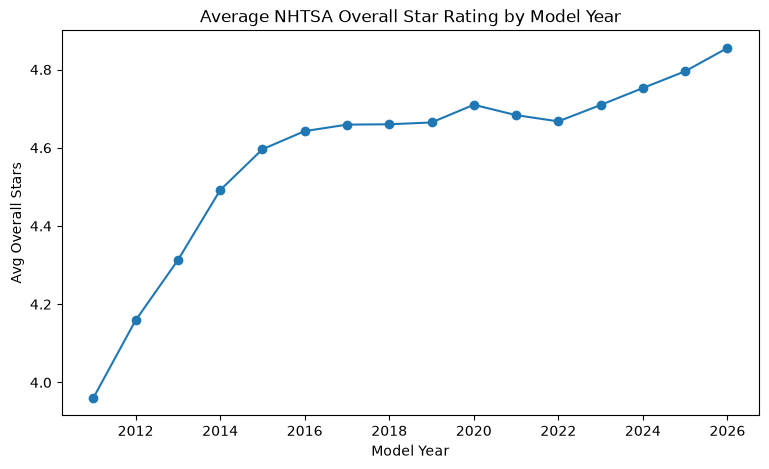

In [2]:
trend = con.execute("""
    SELECT MODEL_YR, AVG(OVERALL_STARS) AS avg_overall_stars, COUNT(*) AS n
    FROM vehicles
    WHERE OVERALL_STARS IS NOT NULL
    GROUP BY MODEL_YR
    ORDER BY MODEL_YR
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trend["MODEL_YR"], trend["avg_overall_stars"], marker="o")
ax.set_xlabel("Model Year")
ax.set_ylabel("Avg Overall Stars")
ax.set_title("Average NHTSA Overall Star Rating by Model Year")
plt.show()

## Trend by vehicle type

Same idea, split by `VEHICLE_TYPE` — this is the kind of breakdown that feeds the Tableau filter. Hard-filtered to `PC`/`MPV`/`TRUCK`, the only raw `VEHICLE_TYPE` codes with real volume in the crash-tested subset (everything else, e.g. `SUV`/`VAN`/stray body-style codes like `"4 DR"`, has single-digit counts and would just be noise on a trend line).

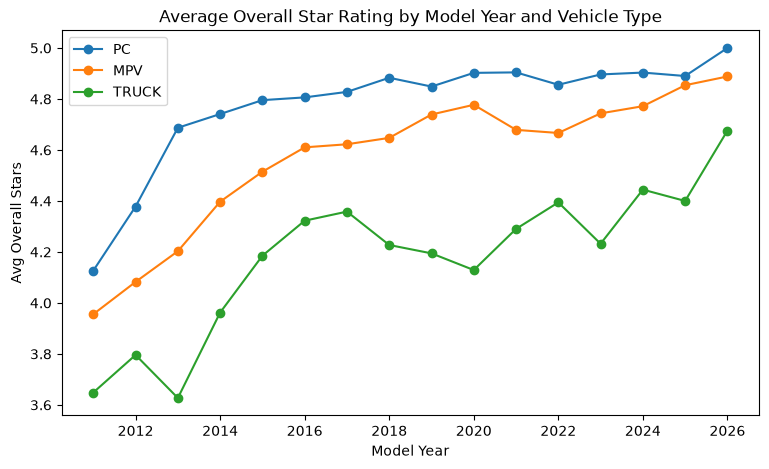

In [3]:
by_type = con.execute("""
    SELECT MODEL_YR, VEHICLE_TYPE, AVG(OVERALL_STARS) AS avg_overall_stars, COUNT(*) AS n
    FROM vehicles
    WHERE OVERALL_STARS IS NOT NULL AND VEHICLE_TYPE IN ('PC', 'MPV', 'TRUCK')
    GROUP BY MODEL_YR, VEHICLE_TYPE
    ORDER BY MODEL_YR
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
for vtype in ["PC", "MPV", "TRUCK"]:
    subset = by_type[by_type["VEHICLE_TYPE"] == vtype]
    ax.plot(subset["MODEL_YR"], subset["avg_overall_stars"], marker="o", label=vtype)
ax.set_xlabel("Model Year")
ax.set_ylabel("Avg Overall Stars")
ax.set_title("Average Overall Star Rating by Model Year and Vehicle Type")
ax.legend()
plt.show()

## Preview: equipment values that need classification (Phase 2)

The `equipment` long table makes it trivial to pull the distinct free-text values for any column the keyword matcher struggles with — this is the exact query Phase 2's `classify_equipment.py` will run to build its problem set.

In [4]:
con.execute("""
    SELECT feature, COUNT(DISTINCT raw_value) AS n_distinct_values
    FROM equipment
    WHERE feature IN ('ABS', 'SEAT_BELT_PRETENSIONER', 'DAY_RUN_LIGHTS')
    GROUP BY feature
    ORDER BY n_distinct_values DESC
""").df()

,feature,n_distinct_values
0,DAY_RUN_LIGHTS,23
1,ABS,15
2,SEAT_BELT_PRETENSIONER,11


## Does the equipment score track crash-test performance?

`vehicle_equipment_score` (mean equipment level, 0-2, across `CORE_FEATURES`) combines rule-based and LLM classifications. To check whether the LLM step actually changed anything beyond filling in coverage, compare it against a rule-only version of the same score, against `OVERALL_STARS`. Correlations are also broken out by 5-year model-year bins, since both equipment richness and star ratings trend upward over time independently — a pooled correlation would mostly be picking up that shared time trend rather than a real relationship.

In [5]:
import pandas as pd

scored = con.execute("""
    WITH scores AS (
        SELECT
            vehicle_id,
            AVG(level) AS score_full,
            AVG(CASE WHEN source = 'rule' THEN level END) AS score_rule_only
        FROM equipment_levels
        GROUP BY vehicle_id
    )
    SELECT v.MODEL_YR, v.OVERALL_STARS, s.score_full, s.score_rule_only
    FROM vehicles v JOIN scores s USING (vehicle_id)
    WHERE v.OVERALL_STARS IS NOT NULL
""").df()

print(f"{len(scored)} crash-tested vehicles with an equipment score")
print(f"corr(score_full, OVERALL_STARS)      = {scored['score_full'].corr(scored['OVERALL_STARS']):.3f}")
print(f"corr(score_rule_only, OVERALL_STARS) = {scored['score_rule_only'].corr(scored['OVERALL_STARS']):.3f}")

scored["yr_bin"] = (scored["MODEL_YR"] // 5) * 5
by_bin = scored.groupby("yr_bin").apply(
    lambda d: pd.Series({
        "n": len(d),
        "corr_full": d["score_full"].corr(d["OVERALL_STARS"]),
        "corr_rule_only": d["score_rule_only"].corr(d["OVERALL_STARS"]),
    })
)
by_bin

5480 crash-tested vehicles with an equipment score
corr(score_full, OVERALL_STARS)      = 0.059
corr(score_rule_only, OVERALL_STARS) = 0.052


,n,corr_full,corr_rule_only
yr_bin,,,
2010,1152.0,-0.206920,-0.229314
2015,1802.0,-0.056883,-0.056049
2020,1857.0,0.274574,0.287562
2025,669.0,0.208767,0.251734


**What this shows:** the pooled correlation between equipment score and `OVERALL_STARS` is weak (~0.06) and misleading on its own — within 5-year model-year bins it swings from negative (2010-2014) to near zero (2015-2019) to positive (2020+), so a single overall number would have hidden a real shift in the relationship over time. Separately, `score_full` and `score_rule_only` differ by only ~0.014 on average (out of a 0-2 scale) — the LLM step barely moved the aggregate number. Its value was in *completeness and correctness*, not in changing this particular headline stat: it took equipment coverage from ~94% to 100% within `CORE_FEATURES`, and it fixed a specific rule-matcher error (bare `"A"` for ABS, 422 records, wrongly assumed to mean "standard") that the rules alone would have silently gotten wrong forever.